In [1]:
# Downloading dataset using Roboflow API

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="T995OvIMt4crQOUYgNE1")
project = rf.workspace("faysels-workspace").project("soda-bottles-zygh-1j24c")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to soda-bottles-zygh-1 in yolov8:: 100%|██████████| 6074/6074 [00:01<00:00, 5408.70it/s]


In [2]:
# installing ultralytics
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.6 MB/s eta 0:00:00


In [3]:
# import neccessary libraries
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import numpy as np


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
DATASET_PATH = "/content/soda-bottles-zygh-1"
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")

print(DATA_YAML)

/content/soda-bottles-zygh-1/data.yaml


In [17]:
# creating a function for the three different models to train
def train_and_evaluate(model_name, run_name, data_yaml, epochs=10):

    print(f"\n===== Training {model_name} =====")

    model = YOLO(model_name)

    # Train
    results = model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=640,
        batch=16,
        name=run_name
    )

    # Get actual save directory automatically
    save_dir = results.save_dir

    # Build correct best.pt path
    best_model_path = os.path.join(save_dir, "weights", "best.pt")

    # Load trained model safely
    trained_model = YOLO(best_model_path)

    # Validate
    metrics = trained_model.val(data=data_yaml)

    return {
        "Model": model_name,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr
    }


In [20]:
# train the model by calling the above function
DATASET_PATH = "/content/soda-bottles-zygh-1"
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")

results_n = train_and_evaluate("yolov8n.pt", "exp_n", DATA_YAML, epochs=10)
results_s = train_and_evaluate("yolov8s.pt", "exp_s", DATA_YAML, epochs=10)
results_m = train_and_evaluate("yolov8m.pt", "exp_m", DATA_YAML, epochs=10)




===== Training yolov8n.pt =====
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/soda-bottles-zygh-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

In [23]:
# comparing the three differnt models
import pandas as pd

comparison_df = pd.DataFrame([results_n, results_s, results_m])
comparison_df


,Model,mAP50,mAP50-95,Precision,Recall
0,yolov8n.pt,0.955358,0.541562,0.938354,0.932035
1,yolov8s.pt,0.954438,0.547696,0.941435,0.930363
2,yolov8m.pt,0.955319,0.550133,0.942430,0.931002


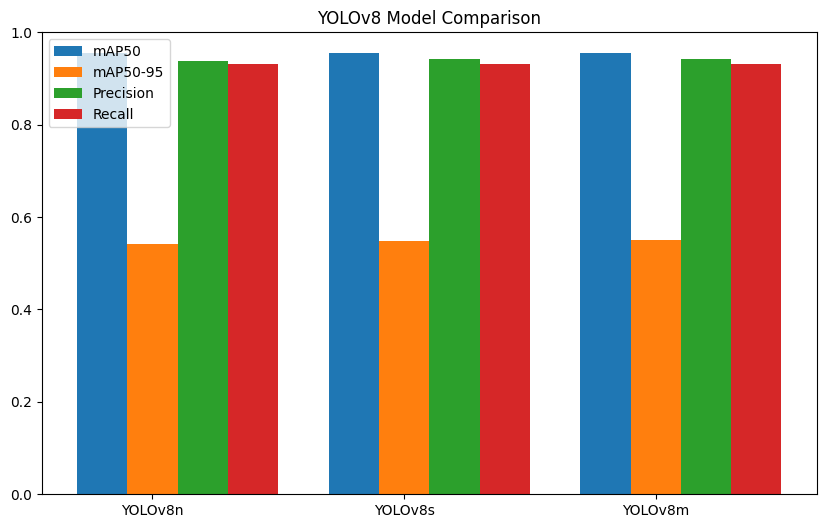

In [22]:
# let visualize our comparision table using a bar chart
metrics_labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']

models = ['YOLOv8n', 'YOLOv8s', 'YOLOv8m']

values = [
    [results_n['mAP50'], results_s['mAP50'], results_m['mAP50']],
    [results_n['mAP50-95'], results_s['mAP50-95'], results_m['mAP50-95']],
    [results_n['Precision'], results_s['Precision'], results_m['Precision']],
    [results_n['Recall'], results_s['Recall'], results_m['Recall']]
]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))

for i in range(len(metrics_labels)):
    ax.bar(x + i*width, values[i], width, label=metrics_labels[i])

ax.set_xticks(x + width)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.set_title("YOLOv8 Model Comparison")
ax.legend()

plt.show()


In [24]:
# create a function to show sample predictions
import random
import cv2
import matplotlib.pyplot as plt

def show_sample_predictions(model_path, test_images_path, num_images=5):

    from ultralytics import YOLO

    model = YOLO(model_path)

    images = os.listdir(test_images_path)
    sample_images = random.sample(images, num_images)

    print(f"\nShowing predictions using model: {model_path}\n")

    for img_name in sample_images:
        img_path = os.path.join(test_images_path, img_name)

        results = model(img_path)

        for r in results:
            im_array = r.plot()

            plt.figure(figsize=(6,6))
            plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
            plt.title(f"Prediction: {img_name}")
            plt.axis("off")
            plt.show()



Showing predictions using model: /content/runs/detect/exp_s/weights/best.pt


image 1/1 /content/soda-bottles-zygh-1/test/images/01_20220315_222655_bmp_jpg.rf.3c8a87b901d831d22a2aab393d02660c.jpg: 640x640 8 coca-colas, 8 fantas, 12 sprites, 16.1ms
Speed: 2.0ms preprocess, 16.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


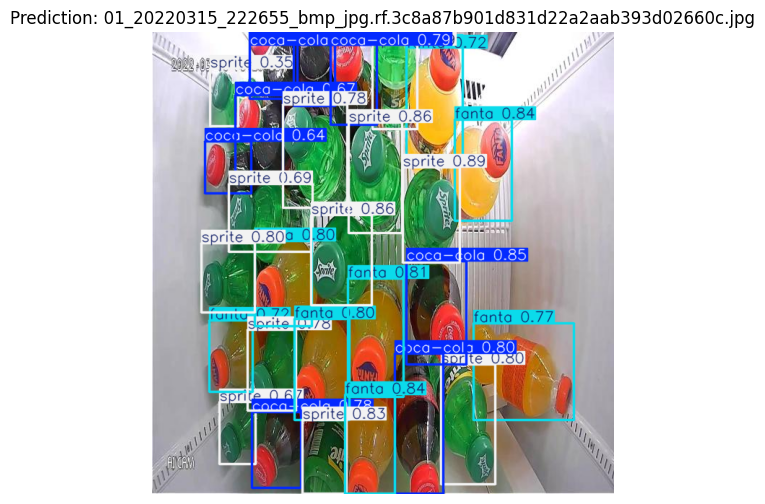


image 1/1 /content/soda-bottles-zygh-1/test/images/01_20220317_141551_bmp_jpg.rf.d02d5e04f9bf29e7525b8d0558da81c0.jpg: 640x640 4 coca-colas, 5 fantas, 4 sprites, 20.0ms
Speed: 8.5ms preprocess, 20.0ms inference, 6.0ms postprocess per image at shape (1, 3, 640, 640)


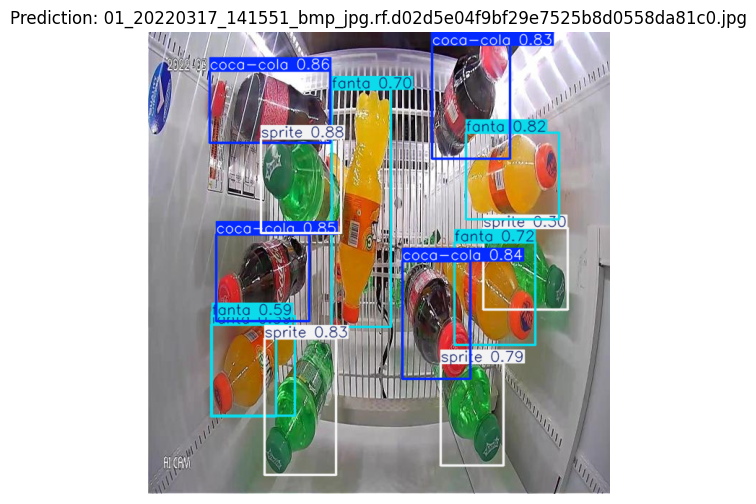


image 1/1 /content/soda-bottles-zygh-1/test/images/01_20220317_140603_bmp_jpg.rf.dc3b80081ee0b3078cbbfefc5939f2e4.jpg: 640x640 4 coca-colas, 4 fantas, 5 sprites, 16.3ms
Speed: 2.8ms preprocess, 16.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


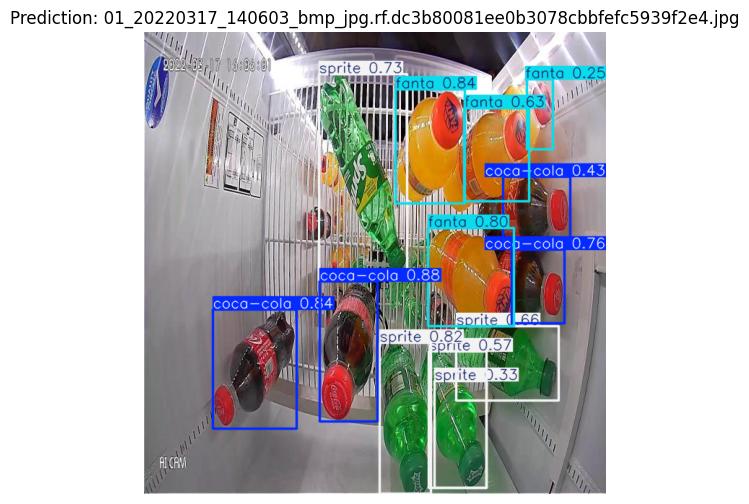


image 1/1 /content/soda-bottles-zygh-1/test/images/01_20220314_202524_bmp_jpg.rf.bc3561e7b08f10cc46222b9a6926fd65.jpg: 640x640 13 coca-colas, 14 fantas, 10 sprites, 16.3ms
Speed: 4.5ms preprocess, 16.3ms inference, 3.9ms postprocess per image at shape (1, 3, 640, 640)


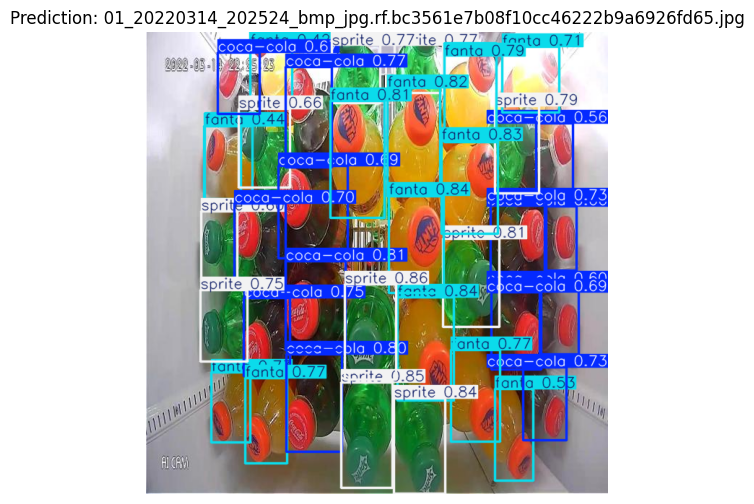


image 1/1 /content/soda-bottles-zygh-1/test/images/01_20220314_191008_bmp_jpg.rf.0345fb429ec605fc78a5e4c79416c0e5.jpg: 640x640 10 coca-colas, 12 fantas, 15 sprites, 16.6ms
Speed: 4.0ms preprocess, 16.6ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 640)


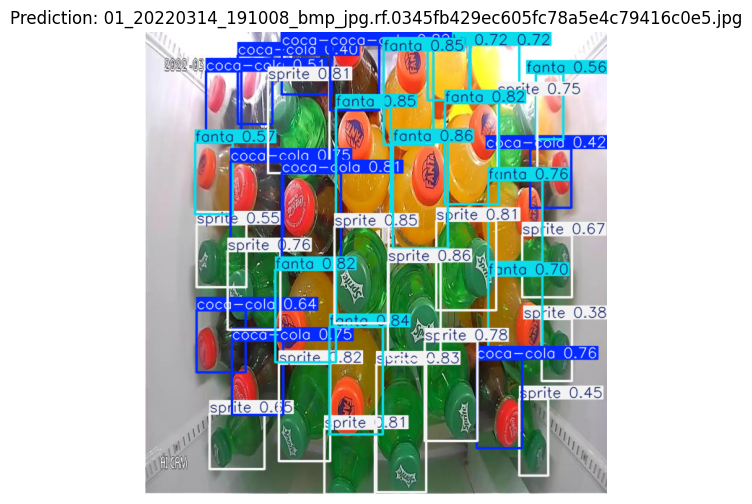

In [26]:
# let us see the predictions of the best model
TEST_IMAGES = os.path.join(DATASET_PATH, "test/images")
show_sample_predictions(
    "/content/runs/detect/exp_s/weights/best.pt",
    TEST_IMAGES,
    num_images=5
)
